# Brazilian E-Commerce Analysis

## Dataset

- This is a Brazilian ecommerce public dataset of orders made at Olist Store.
- The dataset has information of 100k orders from 2016 to 2018 made at multiple marketplaces in Brazil.
- The data was sourced from Kaggle.

## Problem Statement

This project aims to analyze customer behavior, sales performance, and retention patterns in a Brazilian e-commerce business. The analysis seeks to answer the following questions:

- What are the overall sales and order trends over time?
- Which product categories and regions generate the most revenue?
- How efficient is the order fulfillment and delivery process?Who are the most valuable customers based on purchasing behavior?
- How effectively does the business retain customers over time?
- What actionable insights can support customer retention and revenue growth?

## Importing Required Libraries

In [1]:
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

### The raw CSV files are loaded into separate DataFrames corresponding to the original Olist relational tables.

In [2]:
customers = pd.read_csv("data/olist_customers_dataset.csv")
geolocation = pd.read_csv("data/olist_geolocation_dataset.csv")
orders = pd.read_csv("data/olist_orders_dataset.csv")
order_items = pd.read_csv("data/olist_order_items_dataset.csv")
payments = pd.read_csv("data/olist_order_payments_dataset.csv")
reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")
products = pd.read_csv("data/olist_products_dataset.csv")
sellers = pd.read_csv("data/olist_sellers_dataset.csv")
category_translation = pd.read_csv("data/product_category_name_translation.csv")

## Data Quality Assessment

### Dataset Overview 

In [3]:
tables = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "category_translation": category_translation
}

quality_summary = []

for name, df in tables.items():
    quality_summary.append({
        "table": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_values": df.isna().sum().sum(),
        "duplicates": df.duplicated().sum()

    })

quality_report = pd.DataFrame(quality_summary)

quality_report

,table,rows,columns,missing_values,duplicates
0,customers,99441,5,0,0
1,orders,99441,8,4908,0
2,order_items,112650,7,0,0
3,payments,103886,5,0,0
4,reviews,99224,7,145903,0
5,products,32951,9,2448,0
6,sellers,3095,4,0,0
7,geolocation,1000163,5,0,261831
8,category_translation,71,2,0,0


### Data Types Assessment

In [4]:
dtype_report = []

for name, df in tables.items():
    for col, dtype in df.dtypes.items():
        dtype_report.append({
            "table": name,
            "column": col,
            "dtype": str(dtype)
        })

dtype_report = pd.DataFrame(dtype_report)
dtype_report

,table,column,dtype
0,customers,customer_id,object
1,customers,customer_unique_id,object
2,customers,customer_zip_code_prefix,int64
3,customers,customer_city,object
4,customers,customer_state,object
5,orders,order_id,object
6,orders,customer_id,object
7,orders,order_status,object
8,orders,order_purchase_timestamp,object
9,orders,order_approved_at,object


## Data Cleaning

### Handling Missing Values

#### Missing values in orders table

In [5]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

#### Investigation

In [6]:
orders["order_status"].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [7]:
orders.loc[orders["order_status"] != "delivered"].isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 146
order_delivered_carrier_date     1781
order_delivered_customer_date    2957
order_estimated_delivery_date       0
dtype: int64

Most missing values belong to orders with statuses other than delivered (e.g. canceled, unavailable, processing), where the absence of delivery dates is expected and does not indicate a data quality issue.

In [8]:
orders.loc[orders["order_status"] =="delivered"].isna().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64

Only a very small number of delivered orders contained missing timestamps (14 missing approval dates, 2 missing carrier dates, and 8 missing customer delivery dates). Due to the negligible volume of affected records (~0,02%), these observations were retained in the dataset and excluded only from analyses requiring delivery dates.

#### Missing values in reviews table


In [9]:
reviews.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [10]:
reviews.loc[
    reviews["review_comment_title"].isna()|
    reviews["review_comment_message"].isna(),
    "review_score"
].value_counts(normalize=True) * 100

review_score
5    58.070146
4    19.812049
1    10.779214
3     8.325782
2     3.012810
Name: proportion, dtype: float64

In [11]:
reviews.loc[
    reviews["review_comment_title"].isna(),
    "review_score"
].value_counts(normalize=True).mul(100).round(2)

review_score
5    57.81
4    19.86
1    10.90
3     8.39
2     3.05
Name: proportion, dtype: float64

In [12]:
reviews.loc[
        reviews["review_comment_title"].isna(),
        "review_score"
].value_counts(normalize=True).mul(100)

review_score
5    57.805512
4    19.858310
1    10.896003
3     8.390755
2     3.049420
Name: proportion, dtype: float64

The reviews dataset contains a large number of missing values in review_comment_title and review_comment_message.
Investigation showed that missing textual feedback is primarily associated with high review scores (4–5 stars), indicating that satisfied customers often submit ratings without comments.
Since the project focuses on numerical review scores rather than text mining, no action was taken regarding missing review comments.

#### Missing values in product table

In [13]:
products.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [14]:
products.loc[
    products["product_category_name"].isna(),
    [
        "product_name_lenght",
        "product_description_lenght",
        "product_photos_qty"
    ]
].isna().all()

product_name_lenght           True
product_description_lenght    True
product_photos_qty            True
dtype: bool

Missing values in product metadata columns (product_category_name, product_name_length, product_description_length, and product_photos_qty) occur for the same 610 products, indicating missing catalog information rather than isolated data quality issues. Since these attributes are not required for the planned customer and sales analyses, no imputation was performed.

### Removing Duplicates

#### Duplicates in geolocation table

In [15]:
print("Rows before:", geolocation.shape[0])

geolocation = geolocation.drop_duplicates()

print("Rows after:", geolocation.shape[0])

Rows before: 1000163
Rows after: 738332


The geolocation table contained 261,831 duplicate records. Duplicate rows were removed to improve data quality and reduce dataset size.

### Fixing Data Types

In [16]:
date_columns = ["order_purchase_timestamp","order_approved_at","order_delivered_carrier_date","order_delivered_customer_date","order_estimated_delivery_date"]
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"])

reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"])
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"])

#### Validation

In [17]:
orders[date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [18]:
order_items["shipping_limit_date"].dtypes

dtype('<M8[ns]')

In [19]:
reviews.dtypes

review_id                          object
order_id                           object
review_score                        int64
review_comment_title               object
review_comment_message             object
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object

All timestamp columns were successfully converted to datetime format.

### Feature Engineering

Creating a dataset called `delivery_orders` containing only delivered orders for delivery performance analysis.

In [20]:
delivery_orders = orders.loc[orders["order_status"] == "delivered"].copy()
delivery_orders = delivery_orders.dropna(subset= ["order_delivered_customer_date"]).copy()

Creating the features `delivery_days` and `delay_days`:
- `delivery_days` represents the number of days between purchase and delivery.
- `delay_days` represents the difference between the actual delivery date and estimated delivery date.

Creating the feature `delivery_status`, which classifies orders as:
- Early 
- On time
- Delayed

Used NumPy's `np.select()` function to apply vectorized conditional logic, which is more efficient than row-wise .apply() operations in pandas.

In [21]:
delivery_orders["delivery_days"] = (delivery_orders["order_delivered_customer_date"] - delivery_orders["order_purchase_timestamp"]).dt.days
delivery_orders["delay_days"] = (delivery_orders["order_delivered_customer_date"]-delivery_orders["order_estimated_delivery_date"]).dt.days

In [22]:
conditions = [
    delivery_orders['delay_days'] < 0,
    delivery_orders['delay_days'] == 0,
]
choices = ['Early','On Time']

delivery_orders['delivery_status'] = np.select(conditions, choices, default='Delayed')

The `delivery_status` feature was created to facilitate the analysis of delivery performance and customer satisfaction.

Creating a customer-level dataset called `customer_metrics` containing:
- Customer ID
- Total amount spent
- Total number of orders
- Average order value

In [24]:
# Calculate total order value
order_value = (
    payments
    .groupby("order_id", as_index=False)["payment_value"]
    .sum()
    .rename(columns = {"payment_value":"order_value"})
)

# Merge order_value feature to order table

orders = (
    orders
    .merge(order_value, on="order_id", how="left")
)


# Create customer-level metrics table 
customer_metrics= (
    orders
    .merge(customers, how = "left", on = "customer_id")
    .groupby("customer_unique_id", as_index=False)
    .agg(
        total_spent = ("order_value","sum"),
        total_orders = ("order_id","nunique")
    )

)
# Create the feautre "average_order_value"
customer_metrics["avg_order_value"] = (
    customer_metrics["total_spent"]
    / customer_metrics["total_orders"]
).round(2)

### Summary of engineered features
- `delivery_orders`
- `delivery_days`
- `delay_days`
- `delivery_status`
- `order_value`
- `customer_metric`

## RFM Analysis

In [25]:
# Keeping only delivered orders for RFM analysis
rfm_orders = (
    orders
    .merge(customers, on="customer_id", how="left")
)

rfm_orders = rfm_orders.loc[
    rfm_orders["order_status"] == "delivered"
].copy()

### RECENCY

In [26]:
recency_df = (
    rfm_orders
    .groupby("customer_unique_id", as_index=False)["order_purchase_timestamp"]
    .max()
)
reference_date = recency_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
recency_df["recency"] = (reference_date - recency_df["order_purchase_timestamp"]).dt.days
recency_df = recency_df.drop(columns = 'order_purchase_timestamp', axis = 'columns')
recency_df.head()

,customer_unique_id,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,112
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115
2,0000f46a3911fa3c0805444483337064,537
3,0000f6ccb0745a6a4b88665a16c9f078,321
4,0004aac84e0df4da2b147fca70cf8255,288


### FREQUENCY

In [27]:
frequency_df = (
    rfm_orders
    .groupby("customer_unique_id", as_index=False)["order_id"]
    .nunique()
    .rename(columns = {"order_id":"frequency"}) 
)
frequency_df.head()

,customer_unique_id,frequency
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


### MONETARY

In [28]:
monetary_df = (
    rfm_orders
        .groupby("customer_unique_id", as_index=False)
        .agg(
            monetary=("order_value","sum")
        )
)

### RFM Scoring

In [29]:
rfm_df = (
    recency_df
    .merge(frequency_df, on = "customer_unique_id")
    .merge(monetary_df, on = "customer_unique_id")
)
rfm_df.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


Recency and Monetary values were divided into tertiles using `pd.qcut()`.

For Recency:
- Score 3 = most recent customers
- Score 2 = moderately recent customers
- Score 1 = least recent customers

For Monetary:
- Score 1 = lowest spenders
- Score 2 = medium spenders
- Score 3 = highest spenders

In [30]:
# Lower recency values indicate more recent purchases, therefore scores are assigned in reverse order.
rfm_df["recency_score"] = pd.qcut(rfm_df["recency"], q = 3, labels = [3,2,1])

In [31]:
rfm_df["monetary_score"] = pd.qcut(rfm_df["monetary"], q = 3, labels = [1,2,3])

The purchase frequency distribution is highly skewed. Approximately 97% of customers placed only one order.


In [32]:
repeat_rate = (
    (frequency_df["frequency"] > 1).mean()
) * 100

print(f"Repeat customer rate: {repeat_rate:.2f}%")

Repeat customer rate: 3.00%


**Key finding:**

Approximately 97% of customers placed only one order, while only 3.0% made a repeat purchase. Due to this highly skewed distribution, a traditional quantile-based frequency scoring approach would not produce meaningful customer groups.

Frequency were therefore classified into:
- Score 1 = One-time customers
- Score 2 = Repeat customers

In [33]:
rfm_df['frequency_score'] = np.where(
    rfm_df['frequency'] == 1,
    1,
    2
)

### RFM Segments

Customer segments were defined using custom business rules based on Recency, Frequency, and Monetary scores.

| Segment | Recency Score | Frequency Score | Monetary Score |
|----------|----------|----------|----------|
| Champions | 3 | 2 | 3 |
| New Customers | 3 | 1 | Any |
| Lost Customers | 1 | 1 | Any |
| Loyal Customers | Any | 2 | Any |
| Big Spenders | Any | Any | 3 |
| Regular | Other combinations | Other combinations | Other combinations |

In [34]:
def customer_segment(row):
    r = int(row["recency_score"])
    f = int(row["frequency_score"])
    m = int(row["monetary_score"])

    if r == 3 and f == 2 and m == 3:
        return "Champions"

    elif r == 3 and f == 1:
        return "New Customers"

    elif r == 1 and f == 1:
        return "Lost Customer"

    elif f == 2:
        return "Loyal Customers"

    elif m == 3:
        return "Big Spenders"

    else:
        return "Regular"


rfm_df["segment"] = rfm_df.apply(customer_segment, axis=1)

In [35]:
seg_count = rfm_df["segment"].value_counts().reset_index()
seg_count['percentage'] = (
    seg_count['count']/
    seg_count['count'].sum()
    * 100
)
seg_count = seg_count.sort_values(
    "count",
    ascending=False
)
seg_count

,segment,count,percentage
0,New Customers,30310,32.466420
1,Lost Customer,30157,32.302534
2,Regular,20437,21.891000
3,Big Spenders,9653,10.339767
4,Loyal Customers,2037,2.181923
5,Champions,764,0.818355


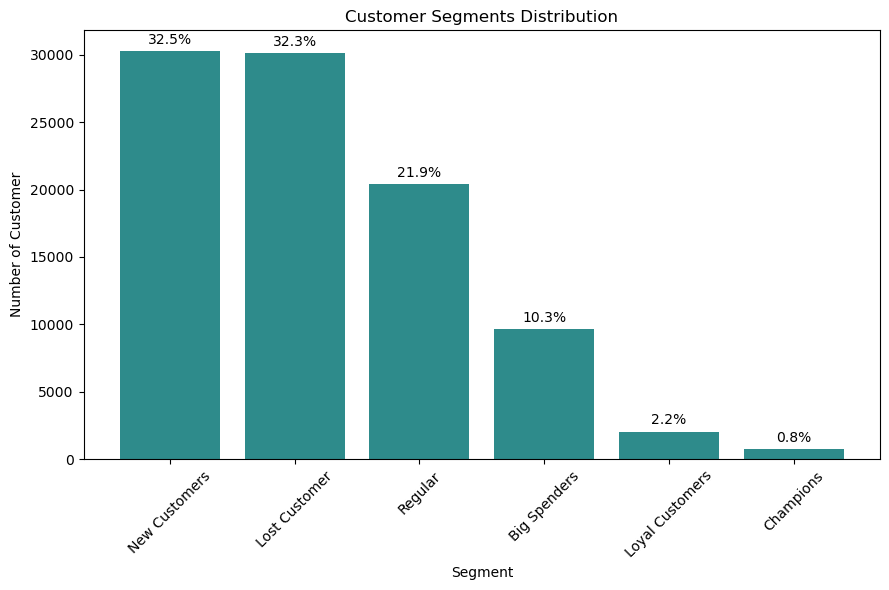

In [36]:
fig, ax = plt.subplots(figsize = (9,6))

bars = ax.bar(
    seg_count['segment'],
    seg_count['count'],
    color = "#2E8B8B"
)

ax.bar_label(
    bars,
    labels = [f"{x:.1f}%" for x in seg_count['percentage']],
    padding=3
)
ax.set_title("Customer Segments Distribution")
ax.set_xlabel("Segment")
ax.set_ylabel("Number of Customer")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Key findings:**

- The largest segments are New Customers and Lost Customers, indicating a high customer turnover rate.
- Champions represent only a small fraction of the customer base, reflecting the low repeat purchase rate observed earlier.
- The relatively small Loyal Customers segment suggests limited long-term customer engagement.
- A substantial number of Big Spenders exist despite low purchase frequency, indicating that some customers generate significant revenue through a small number of purchases.

## COHORT ANALYSIS

**Creating the cohort_data dataset**

A new dataset, `cohort_data`, was created containing only the columns required for cohort analysis.

In [37]:
cohort_data = (
    orders
    .merge(customers, on = "customer_id", how = "left")
    [["order_id", "customer_unique_id", "order_purchase_timestamp"]]
    .copy()
)

**Creating the cohort feature**

The `cohort` feature represents the month of each customer's first purchase and is derived by grouping records by customer_unique_id.

In [38]:
cohort_data["cohort"] = cohort_data.groupby("customer_unique_id")['order_purchase_timestamp'].transform('min').dt.to_period('M')

**Creating the order_month feature**

The `order_month` feature represents the month in which each order was placed.

In [39]:
cohort_data['order_month'] = cohort_data['order_purchase_timestamp'].dt.to_period('M')

**Creating the cohort summary table**

Customers were aggregated by cohort and order_month, and the number of unique customers was calculated for each group.

In [40]:
cohorts = (
    cohort_data.groupby(["cohort", "order_month"])
    .agg(customers = ("customer_unique_id","nunique"))
    .reset_index()
)

**Creating the period feature**

The `period` feature represents the number of months since a customer's first purchase.

In [41]:
from operator import attrgetter

cohorts['period'] = (cohorts['order_month'] - cohorts['cohort']).apply(attrgetter('n'))

In [42]:
cohort_pivot = cohorts.pivot(
	index="cohort", columns="period", values="customers"
)

In [43]:
# Checking cohort sizes
cohort_sizes = cohort_pivot.iloc[:,0]

Cohorts with fewer than 30 customers were excluded from the retention visualization because retention rates based on very small sample sizes are unstable and may be misleading.

In [44]:
valid_cohort_sizes = cohort_sizes.loc[cohort_sizes > 30]

In [45]:
# Filtering cohort_pivot table to contain only valid cohorts (>30 customers)
cohort_pivot = cohort_pivot.loc[cohort_pivot.index.isin(valid_cohort_sizes.index)]

In [46]:
retention_matrix = cohort_pivot.divide(
    valid_cohort_sizes,
    axis=0
)

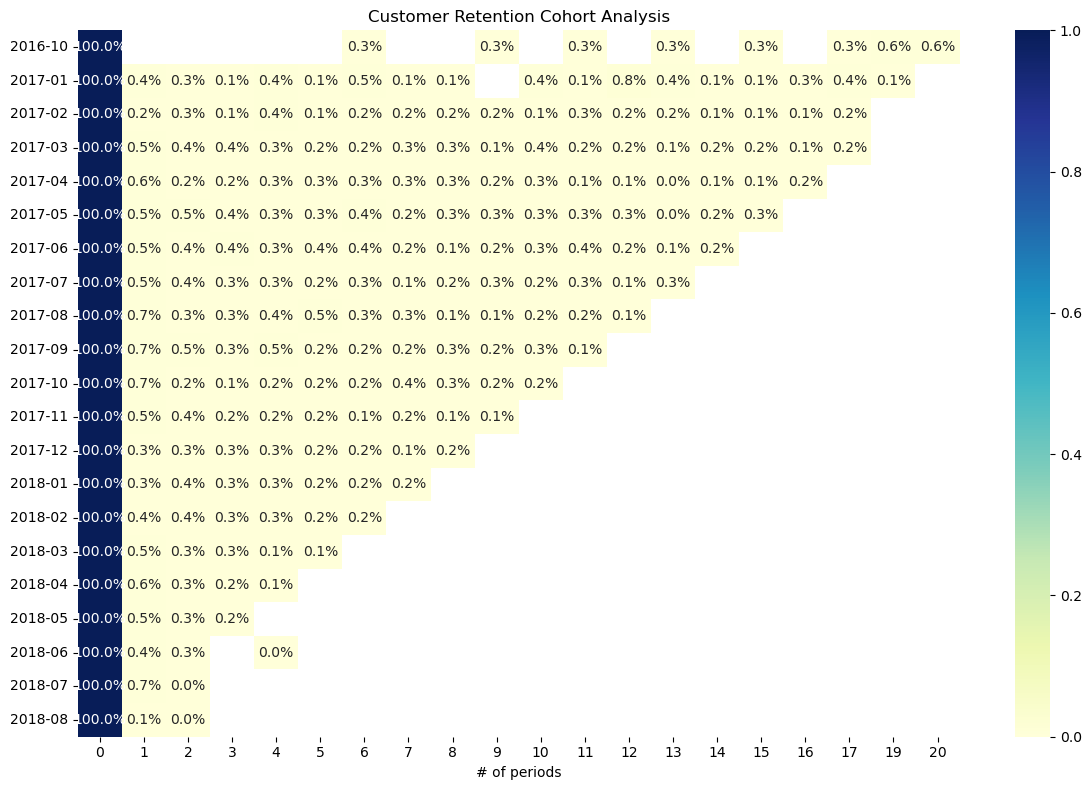

In [47]:
fig, ax = plt.subplots(figsize=(12,8))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1%',
    cmap='YlGnBu',
    vmin = 0,
    vmax = 1
)

ax.set_title('Customer Retention Cohort Analysis')
ax.set(xlabel='# of periods',
              ylabel='')
fig.tight_layout()
plt.show()

**Key finding:**

The cohort analysis confirms the earlier observation that repeat purchases were rare, with retention rates remaining below 1% for most cohorts after the first month.

## Exporting data to SQL

### Connecting to the PostgreSQL Database

In [ ]:
from sqlalchemy import create_engine

username = 'your_username'
password = 'your_password'
host = 'localhost'
port = '5432'
database = 'E-commerce'

engine = create_engine(
    f'postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}'
    )
    
engine.connect()

### Exporting all tables to PostgreSQL

In [50]:
tables = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation,
    "delivery_orders": delivery_orders,
    "customer_metrics": customer_metrics,
    "rfm": rfm_df
}

for table_name, df in tables.items():
    df.to_sql(
        table_name,
        engine,
        if_exists = 'replace',
        index = False
    )
    